# Single-stream masked JEPA prototype

This notebook is a **small Health&Gait feasibility experiment**. It tests whether a single video stream can learn non-collapsed representations by predicting masked target-encoder features. It intentionally follows the masked V-JEPA training pattern: the context and target encoders see complementary token regions from the same clip.

It is **not** the final CoDy-JEPA model and does not implement counterfactual token swapping, factorized streams, or explicit future-dynamics prediction. Success requires more than falling loss: validation representations must retain variance/effective rank, and shuffling video context must make prediction worse.

`Run All` is safe: it validates data and runs a tiny CPU smoke test. A full CUDA job is enabled with `CODY_JEPA_RUN_FULL_TRAINING=1`; exhaustive frame certification is a separate, opt-in CPU/I/O job so it cannot silently consume the GPU allocation before training.

In [1]:
from pathlib import Path
import json
import math
import os
import random
import sys
import time

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
from torch.utils.data import DataLoader

NOTEBOOK_CWD = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / 'src').exists() else NOTEBOOK_CWD.parent
for import_root in (PROJECT_ROOT, PROJECT_ROOT / 'src'):
    if str(import_root) not in sys.path:
        sys.path.insert(0, str(import_root))

from cody_jepa.data import (
    HealthGaitLoaderConfig,
    audit_healthgait_clip_quality,
    build_healthgait_datasets_from_config,
    build_healthgait_loaders_from_config,
    find_repo_root,
    healthgait_manifest_path,
)
from cody_jepa.single_stream_jepa import (
    DEFAULT_MASK_GROUPS,
    MODEL_ARCHITECTURE,
    build_models,
    load_checkpoint,
    multiblock_mask,
    resolve_device,
    train_jepa,
    video_from_batch,
)

def print_json(payload):
    print(json.dumps(payload, indent=2, sort_keys=True))

def env_flag(name, default=False):
    value = os.environ.get(name)
    if value is None:
        return bool(default)
    normalized = value.strip().casefold()
    if normalized not in {'0', '1', 'false', 'true', 'no', 'yes'}:
        raise ValueError(f'{name} must be a boolean flag; got {value!r}')
    return normalized in {'1', 'true', 'yes'}

RUN_FULL_TRAINING = env_flag('CODY_JEPA_RUN_FULL_TRAINING', False)
RUN_DATA_AUDIT = env_flag('CODY_JEPA_RUN_DATA_AUDIT', not RUN_FULL_TRAINING)
RUN_EXHAUSTIVE_DATA_AUDIT = env_flag(
    'CODY_JEPA_RUN_EXHAUSTIVE_DATA_AUDIT', False
)

CONFIG = {
    'seed': 0,
    # batch_size is a physical microbatch; four microbatches make an effective 64.
    'batch_size': 16,
    'accumulation_steps': 4,
    'steps': 3_900,
    'num_epochs': 100,
    'lr': 1e-4,
    'start_lr': 1e-5,
    'warmup_steps': 200,
    'min_lr': 1e-6,
    'weight_decay': 0.04,
    'grad_clip': 1.0,
    'ema_start': 0.998,
    'ema_end': 1.0,
    'loss_exp': 1.0,

    'num_frames': 16,
    'img_size': 112,
    'patch_size': 8,
    'tubelet_size': 2,
    'in_channels': 1,
    'num_tokens': 1568,
    'min_context_tokens': 64,
    'input_mean': 0.5,
    'input_std': 0.5,

    'embed_dim': 384,
    'hidden_dim': 1536,
    'num_heads': 6,
    'num_layers': 6,
    'pred_dim': 192,
    'pred_depth': 6,
    'dropout': 0.0,
    'uniform_power': True,
    'norm_eps': 1e-6,

    'amp_dtype': 'bfloat16',
    'compile': False,  # enable only after the eager CUDA preflight succeeds
    'tf32': True,
    'required_device': 'cuda',
    'eval_every_epochs': 5,
    'train_eval_every_epochs': 0,
    'checkpoint_every_epochs': 1,
    'shortcut_diagnostic_batches': 1,
    'selection_metric': 'subject_balanced_loss',
    'min_feature_std': 1e-3,
    'max_near_zero_variance_fraction': 0.5,
    'min_effective_rank_ratio': 0.05,
    'min_context_shuffle_loss_gap': 1e-3,
}

assert CONFIG['num_tokens'] == (
    CONFIG['num_frames'] // CONFIG['tubelet_size']
    * (CONFIG['img_size'] // CONFIG['patch_size']) ** 2
)
cuda_preflight = None
if RUN_FULL_TRAINING:
    FULL_TRAINING_DEVICE = resolve_device(CONFIG['required_device'])
    cuda_preflight = {
        'status': 'passed',
        'cuda_device_name': torch.cuda.get_device_name(FULL_TRAINING_DEVICE),
    }
print_json({
    'architecture': MODEL_ARCHITECTURE,
    'effective_batch': CONFIG['batch_size'] * CONFIG['accumulation_steps'],
    'run_full_training': RUN_FULL_TRAINING,
    'run_data_audit': RUN_DATA_AUDIT,
    'run_exhaustive_data_audit': RUN_EXHAUSTIVE_DATA_AUDIT,
    'cuda_preflight': cuda_preflight,
})

{
  "architecture": "cody-jepa-single-stream-masked-v3",
  "cuda_preflight": {
    "cuda_device_name": "NVIDIA H100 80GB HBM3",
    "status": "passed"
  },
  "effective_batch": 64,
  "run_data_audit": false,
  "run_exhaustive_data_audit": false,
  "run_full_training": true
}


In [2]:
REPO_ROOT = find_repo_root()
MANIFEST_CSV = healthgait_manifest_path(REPO_ROOT)
LOADER_CONFIG = HealthGaitLoaderConfig(
    manifest_csv=MANIFEST_CSV,
    repo_root=REPO_ROOT,
    split='train',
    clip_length=CONFIG['num_frames'],
    image_size=(CONFIG['img_size'], CONFIG['img_size']),
    batch_size=CONFIG['batch_size'],
    seed=CONFIG['seed'],
    num_workers=4,
    pin_memory=torch.cuda.is_available(),
    prefetch_factor=1,
    train_crop_scale=(0.90, 1.0),
    train_horizontal_flip_prob=0.5,
    strict_frame_sequence=True,
    image_verify_mode='all' if RUN_EXHAUSTIVE_DATA_AUDIT else 'sample',
    inventory_hash_mode='full' if RUN_EXHAUSTIVE_DATA_AUDIT else 'sample',
    allowed_data_root=REPO_ROOT / 'data' / 'healthgait',
    eval_windows=3,
    drop_last_train=True,
)

# Build each dataset once; the validation dataset reuses the validated manifest inventory.
train_ds, val_ds = build_healthgait_datasets_from_config(LOADER_CONFIG)
train_loader, val_loader = build_healthgait_loaders_from_config(
    LOADER_CONFIG, datasets=(train_ds, val_ds)
)
portable_loader_config = {
    key: value
    for key, value in LOADER_CONFIG.as_dict().items()
    if key not in {'manifest_csv', 'repo_root', 'allowed_data_root'}
}
DATA_CONTRACT = {
    'loader_config': portable_loader_config,
    'train_dataset': train_ds.signature(),
    'val_dataset': val_ds.signature(),
}
print_json({
    'train_sequences': len(train_ds.samples),
    'train_clips_per_epoch': len(train_ds),
    'val_sequences': len(val_ds.samples),
    'val_deterministic_windows': len(val_ds),
    'data_contract': DATA_CONTRACT,
})

{
  "data_contract": {
    "loader_config": {
      "batch_size": 16,
      "channels": 1,
      "clip_length": 16,
      "drop_last_train": true,
      "eval_windows": 3,
      "expected_modality": "silhouette",
      "image_size": [
        112,
        112
      ],
      "image_verify_mode": "sample",
      "inventory_hash_mode": "sample",
      "num_workers": 4,
      "pin_memory": true,
      "prefetch_factor": 1,
      "seed": 0,
      "split": "train",
      "strict_frame_sequence": true,
      "strict_validation": true,
      "train_crop_scale": [
        0.9,
        1.0
      ],
      "train_horizontal_flip_prob": 0.5,
      "window_policy": "train_random_val_center"
    },
    "train_dataset": {
      "dataset_sha256": "0472f7b6b08c9e078d1c28daf2fc626697a0a71c5e6c1ef6140d8c838a0d3963",
      "inventory_sha256": "b46c484e8af0a4e31f0669aa436a92936e1725ee0082d8615065c617bb29576d",
      "manifest_sha256": "3074603602400af0b639c9569d69f5da99f43daebf3980b480154adddfdfb10e",
     

In [3]:
# The all-sequence quality audit is intentionally separate from full training.
# On HAIC it is useful before submission but wastes an allocated H100 if repeated.
quality_summary = (
    audit_healthgait_clip_quality((train_ds, val_ds)) if RUN_DATA_AUDIT else None
)
preflight_loader = DataLoader(train_ds, batch_size=4, shuffle=False, num_workers=0)
preflight_batch = next(iter(preflight_loader))
preflight_video = video_from_batch(
    preflight_batch, torch.device('cpu'), CONFIG, expected_split='train'
)
train_subjects = {sample['subject_id'].casefold() for sample in train_ds.samples}
val_subjects = {sample['subject_id'].casefold() for sample in val_ds.samples}
assert train_subjects.isdisjoint(val_subjects)
assert torch.isfinite(preflight_video).all()
print_json({
    'batch_shape': tuple(preflight_batch['video'].shape),
    'pixel_range': (
        float(preflight_batch['video'].min()),
        float(preflight_batch['video'].max()),
    ),
    'quality_summary': quality_summary,
    'train_subjects': len(train_subjects),
    'val_subjects': len(val_subjects),
})

{
  "batch_shape": [
    4,
    16,
    1,
    112,
    112
  ],
  "pixel_range": [
    0.0,
    1.0
  ],
  "quality_summary": null,
  "train_subjects": 318,
  "val_subjects": 80
}


In [4]:
def smoke_test_training_loop():
    smoke_cfg = {
        **CONFIG,
        'batch_size': 2, 'accumulation_steps': 1, 'steps': 1, 'num_epochs': 1,
        'lr': 1e-3, 'start_lr': 1e-3, 'warmup_steps': 1, 'min_lr': 1e-5,
        'ema_start': 0.9, 'ema_end': 0.9,
        'num_frames': 4, 'img_size': 16, 'patch_size': 4, 'tubelet_size': 2,
        'num_tokens': 32, 'min_context_tokens': 4,
        'embed_dim': 12, 'hidden_dim': 24, 'num_heads': 3, 'num_layers': 1,
        'pred_dim': 12, 'pred_depth': 1,
        'amp_dtype': None, 'compile': False, 'tf32': False,
        'required_device': 'cpu', 'eval_every_epochs': 1,
    }
    generator = torch.Generator().manual_seed(smoke_cfg['seed'])
    train_samples = [{
        'video': torch.rand(4, 1, 16, 16, generator=generator),
        'split': 'train', 'sequence_id': f'train-{index}', 'subject_id': f'T{index}',
    } for index in range(2)]
    val_samples = [{
        'video': torch.rand(4, 1, 16, 16, generator=generator),
        'split': 'val', 'sequence_id': f'val-{index}', 'subject_id': f'V{index}',
    } for index in range(2)]
    smoke_train = DataLoader(
        train_samples, batch_size=2, shuffle=True,
        generator=torch.Generator().manual_seed(smoke_cfg['seed']),
    )
    smoke_val = DataLoader(val_samples, batch_size=2, shuffle=False)
    result = train_jepa(
        smoke_cfg, smoke_train, smoke_val, {'dataset': 'synthetic-smoke-v1'},
        checkpoint_dir=None, device='cpu',
    )
    assert result['global_step'] == 1
    assert result['completed_epochs'] == 1
    assert result['history'][0]['val']['effective_rank'] > 0
    assert not any(p.requires_grad for p in result['target_encoder'].parameters())
    assert all(p.grad is None for p in result['target_encoder'].parameters())
    masks_a = multiblock_mask(smoke_cfg, 2, random.Random(99))
    masks_b = multiblock_mask(smoke_cfg, 2, random.Random(99))
    assert all(torch.equal(a['ctx'], b['ctx']) for a, b in zip(masks_a, masks_b))
    return result['history'][0]

smoke_metrics = smoke_test_training_loop()
print_json({'smoke_metrics': smoke_metrics})

epoch=001 | step=00001 | lr=1.00e-03 | train_loss=0.9037, train_cosine=0.0110 | val_loss=0.8892, effective_rank=1.0, context_shuffle_loss_gap=0.0000
{
  "smoke_metrics": {
    "ema_tau": 0.9,
    "epoch": 1,
    "epoch_seconds": 0.8137512197718024,
    "examples_per_second": 2.457753612413452,
    "grad_norm": 0.630146861076355,
    "lr": 0.001,
    "peak_gpu_memory_mib": null,
    "step": 1,
    "train_cosine": 0.011049497406929731,
    "train_eval": null,
    "train_examples": 2,
    "train_loss": 0.9036521315574646,
    "val": {
      "context_shuffle_batches": 1,
      "context_shuffle_loss_gap": 4.470348358154297e-07,
      "context_shuffle_pairs": 2,
      "cosine": 0.061626359820365906,
      "effective_rank": 1.000002145767212,
      "effective_rank_ratio": 0.08333351214726765,
      "feature_std": 0.0055137635208666325,
      "health_issues": [
        "context_shuffle_gap_below_threshold"
      ],
      "loss": 0.8891515731811523,
      "max_feature_norm": 2.0548927783966064,

In [5]:
# CPU-only structural preflight. The full CUDA run still performs the real BF16
# forward/backward path and fails fast if the selected GPU is unsuitable.
production_masks = multiblock_mask(CONFIG, 2, random.Random(CONFIG['seed']))
for group in production_masks:
    assert group['ctx'].shape[0] == 2 and group['pred'].shape[0] == 2
    assert not torch.isin(group['ctx'][0], group['pred'][0]).any()
production_context, production_target, production_predictor = build_models(
    CONFIG, torch.device('cpu')
)
parameter_counts = {
    'context_encoder': sum(p.numel() for p in production_context.parameters()),
    'target_encoder': sum(p.numel() for p in production_target.parameters()),
    'predictor': sum(p.numel() for p in production_predictor.parameters()),
}
assert production_context.num_patches == CONFIG['num_tokens']
del production_context, production_target, production_predictor
print_json({
    'parameter_counts': parameter_counts,
    'mask_shapes': [(g['label'], tuple(g['ctx'].shape), tuple(g['pred'].shape)) for g in production_masks],
    'input_microbatch_mib': (
        CONFIG['batch_size'] * CONFIG['num_frames'] * CONFIG['img_size'] ** 2 * 4 / 2**20
    ),
})

{
  "input_microbatch_mib": 12.25,
  "mask_shapes": [
    [
      "small_blocks",
      [
        2,
        552
      ],
      [
        2,
        1016
      ]
    ],
    [
      "large_blocks",
      [
        2,
        512
      ],
      [
        2,
        1040
      ]
    ]
  ],
  "parameter_counts": {
    "context_encoder": 10697088,
    "predictor": 2817984,
    "target_encoder": 10697088
  }
}


In [6]:
output_dir_value = os.environ.get(
    'CODY_JEPA_OUTPUT_DIR', 'outputs/single-stream-jepa'
)
OUTPUT_DIR = Path(output_dir_value).expanduser()
if not OUTPUT_DIR.is_absolute():
    OUTPUT_DIR = PROJECT_ROOT / OUTPUT_DIR
resume_value = os.environ.get('CODY_JEPA_RESUME_CHECKPOINT')
RESUME_CHECKPOINT = Path(resume_value).expanduser() if resume_value else None
if RESUME_CHECKPOINT is not None and not RESUME_CHECKPOINT.is_absolute():
    RESUME_CHECKPOINT = PROJECT_ROOT / RESUME_CHECKPOINT

result = None
if RUN_FULL_TRAINING:
    if not torch.cuda.is_available():
        raise RuntimeError('full training requires an allocated CUDA GPU')
    if RESUME_CHECKPOINT is None and (OUTPUT_DIR / 'latest.pt').exists():
        raise FileExistsError(
            f'{OUTPUT_DIR / "latest.pt"} already exists; choose a new OUTPUT_DIR or resume it'
        )
    resume_state = (
        load_checkpoint(RESUME_CHECKPOINT) if RESUME_CHECKPOINT is not None else None
    )

    # Exercise the production BF16 forward/backward path with one real physical
    # microbatch. This reaches the H100 quickly and fails before the long run on
    # incompatible kernels, OOM, non-finite gradients, or broken data transfer.
    preflight_train_batch = next(iter(train_loader))
    preflight_val_batch = next(iter(val_loader))
    preflight_cfg = {
        **CONFIG,
        'accumulation_steps': 1, 'steps': 1, 'num_epochs': 1,
        'warmup_steps': 1, 'eval_every_epochs': 1,
    }
    preflight_started = time.perf_counter()
    preflight_result = train_jepa(
        preflight_cfg,
        [preflight_train_batch],
        [preflight_val_batch],
        {'dataset': 'real-batch-cuda-preflight-v1'},
        checkpoint_dir=None,
        device=FULL_TRAINING_DEVICE,
    )
    torch.cuda.synchronize(FULL_TRAINING_DEVICE)
    cuda_training_preflight = {
        'status': 'passed',
        'seconds': time.perf_counter() - preflight_started,
        'batch_size': int(preflight_train_batch['video'].shape[0]),
        'peak_gpu_memory_mib': preflight_result['history'][0]['peak_gpu_memory_mib'],
        'loss': preflight_result['history'][0]['train_loss'],
    }
    del preflight_result, preflight_train_batch, preflight_val_batch
    torch.cuda.empty_cache()
    print_json({'cuda_training_preflight': cuda_training_preflight})
    print_json({'training_status': 'starting', 'output_dir': str(OUTPUT_DIR)})
    result = train_jepa(
        CONFIG,
        train_loader,
        val_loader,
        DATA_CONTRACT,
        checkpoint_dir=OUTPUT_DIR,
        resume_state=resume_state,
    )
    print_json({
        'latest': str(OUTPUT_DIR / 'latest.pt'),
        'best_loss': str(OUTPUT_DIR / 'best_loss.pt'),
        'best_healthy': str(OUTPUT_DIR / 'best_healthy.pt'),
        'best_epoch': result['best_epoch'],
        'best_val_loss': result['best_val_loss'],
        'best_healthy_epoch': result['best_healthy_epoch'],
        'termination_reason': result['termination_reason'],
    })
else:
    print_json({
        'full_training': 'skipped',
        'next_step': 'Set CODY_JEPA_RUN_FULL_TRAINING=1 on a CUDA worker.',
    })

epoch=001 | step=00001 | lr=1.00e-04 | train_loss=0.8417, train_cosine=-0.0101 | val_loss=0.8021, effective_rank=2.4, context_shuffle_loss_gap=0.0000
{
  "cuda_training_preflight": {
    "batch_size": 16,
    "loss": 0.8417006731033325,
    "peak_gpu_memory_mib": 1716.19873046875,
    "seconds": 6.0759102357551455,
    "status": "passed"
  }
}
{
  "output_dir": "/hai/scratch/tedmui/cody-jepa/outputs/single-stream-jepa-h100-v2",
  "training_status": "starting"
}


epoch=001 | step=00039 | lr=2.72e-05 | train_loss=0.7551, train_cosine=0.2910


epoch=002 | step=00078 | lr=4.48e-05 | train_loss=0.6015, train_cosine=0.6722


epoch=003 | step=00117 | lr=6.25e-05 | train_loss=0.4546, train_cosine=0.8199


epoch=004 | step=00156 | lr=8.01e-05 | train_loss=0.3334, train_cosine=0.8915


...

epoch=096 | step=03744 | lr=1.43e-06 | train_loss=0.2169, train_cosine=0.8958


epoch=097 | step=03783 | lr=1.24e-06 | train_loss=0.2184, train_cosine=0.8939


epoch=098 | step=03822 | lr=1.11e-06 | train_loss=0.2223, train_cosine=0.8899


epoch=099 | step=03861 | lr=1.03e-06 | train_loss=0.2260, train_cosine=0.8865


epoch=100 | step=03900 | lr=1.00e-06 | train_loss=0.2251, train_cosine=0.8883 | val_loss=0.2247, effective_rank=2.3, context_shuffle_loss_gap=0.6584
{
  "best_epoch": 20,
  "best_healthy": "/hai/scratch/tedmui/cody-jepa/outputs/single-stream-jepa-h100-v2/best_healthy.pt",
  "best_healthy_epoch": null,
  "best_loss": "/hai/scratch/tedmui/cody-jepa/outputs/single-stream-jepa-h100-v2/best_loss.pt",
  "best_val_loss": 0.021018099009233997,
  "latest": "/hai/scratch/tedmui/cody-jepa/outputs/single-stream-jepa-h100-v2/latest.pt",
  "termination_reason": "max_steps_at_epoch_boundary"
}


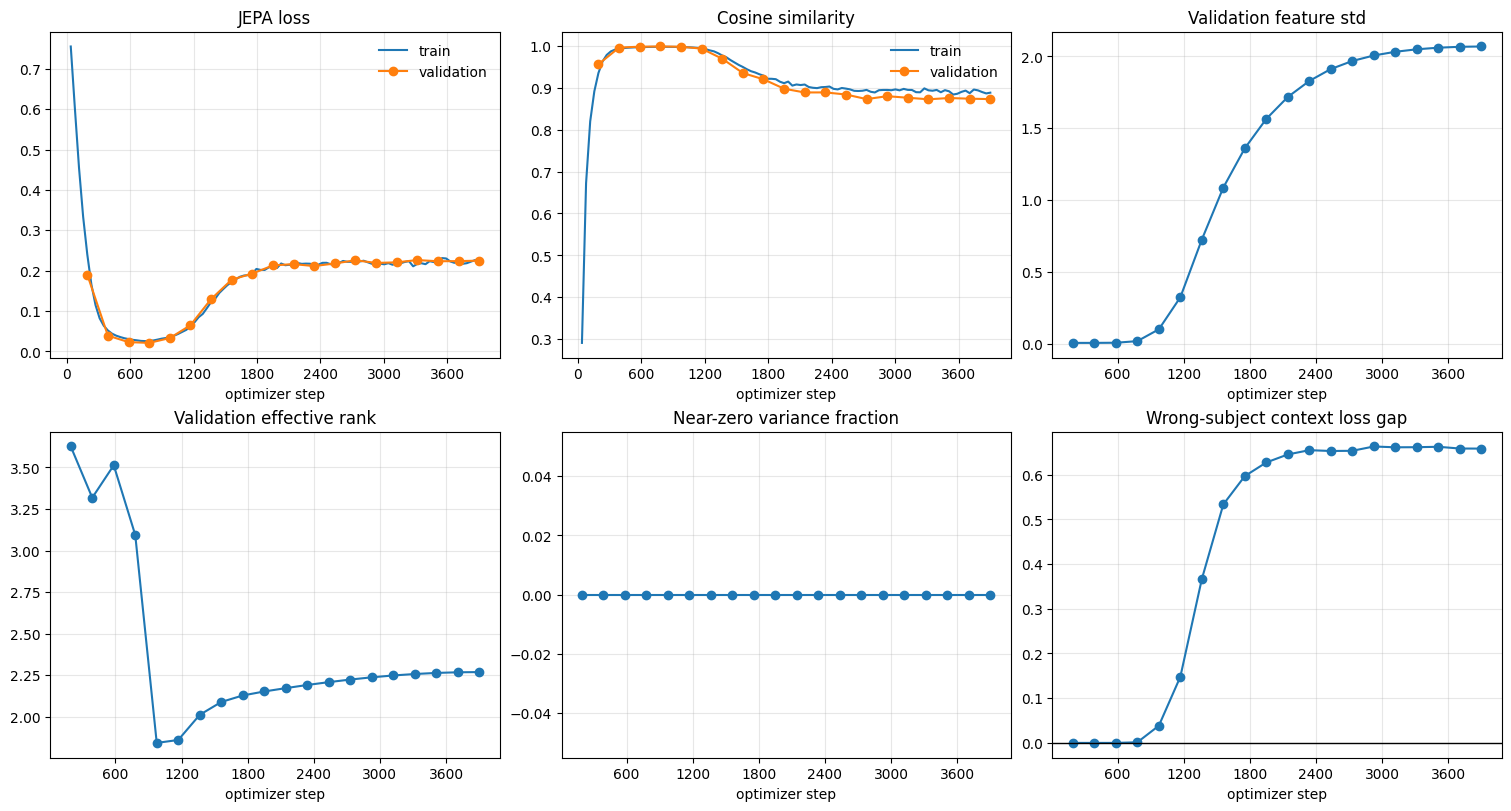

In [7]:
if result is None:
    print_json({'plot_status': 'skipped', 'reason': 'no_full_run_result'})
else:
    history = result['history']
    steps = [row['step'] for row in history]
    train_loss = [row['train_loss'] for row in history]
    train_cosine = [row['train_cosine'] for row in history]
    eval_rows = [row for row in history if row['val'] is not None]
    eval_steps = [row['step'] for row in eval_rows]
    val_loss = [row['val']['loss'] for row in eval_rows]
    val_cosine = [row['val']['cosine'] for row in eval_rows]
    effective_rank = [row['val']['effective_rank'] for row in eval_rows]
    feature_std = [row['val']['feature_std'] for row in eval_rows]
    near_zero_fraction = [row['val']['near_zero_variance_fraction'] for row in eval_rows]
    shuffle_gap = [row['val']['context_shuffle_loss_gap'] for row in eval_rows]

    fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
    axes[0, 0].plot(steps, train_loss, label='train')
    axes[0, 0].plot(eval_steps, val_loss, 'o-', label='validation')
    axes[0, 0].set_title('JEPA loss')
    axes[0, 1].plot(steps, train_cosine, label='train')
    axes[0, 1].plot(eval_steps, val_cosine, 'o-', label='validation')
    axes[0, 1].set_title('Cosine similarity')
    axes[1, 0].plot(eval_steps, effective_rank, 'o-')
    axes[1, 0].set_title('Validation effective rank')
    axes[0, 2].plot(eval_steps, feature_std, 'o-')
    axes[0, 2].set_title('Validation feature std')
    axes[1, 1].plot(eval_steps, near_zero_fraction, 'o-')
    axes[1, 1].set_title('Near-zero variance fraction')
    axes[1, 2].plot(eval_steps, shuffle_gap, 'o-')
    axes[1, 2].axhline(0, color='black', linewidth=1)
    axes[1, 2].set_title('Wrong-subject context loss gap')
    for axis in axes.flat:
        axis.set_xlabel('optimizer step')
        axis.xaxis.set_major_locator(MaxNLocator(8, integer=True))
        axis.grid(True, alpha=0.3)
        if axis.get_legend_handles_labels()[0]:
            axis.legend(frameon=False)
    plt.show()